# 15 — Model Monitoring
## SunnyBest Retail Forecasting System

> **Purpose:** Compare weekly forecasts against actual sales from SunnyX database.  
> Track model accuracy over time and flag weeks where performance degrades.

### How monitoring works

| Step | What happens |
|------|--------------|
| Every Saturday | `generate_weekly_forecast.py` predicts next week's units |
| Following Saturday | Actual sales land in Supabase |
| This notebook | Compares forecast vs actual → computes WAPE, bias, MAE |
| Alert | If WAPE > 20%, the model needs investigation |

### Key metrics
- **MAE** — Mean Absolute Error: average units wrong per store-product per week
- **WAPE** — Weighted Absolute Percentage Error: total error as % of total actual demand
- **Bias** — are we consistently over or under predicting?

---
## 0. Setup

In [12]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sqlalchemy import create_engine
from urllib.parse import quote_plus

plt.rcParams["figure.figsize"]    = (14, 5)
plt.rcParams["axes.spines.top"]   = False
plt.rcParams["axes.spines.right"] = False
PALETTE = ["#4C72B0", "#C44E52", "#55A868", "#DD8452"]

FORECAST_PATH        = "../data/outputs/weekly_forecasts.csv"
WAPE_ALERT_THRESHOLD = 0.20

# ── DB connection ──────────────────────────────────────────
host     = "aws-1-eu-central-1.pooler.supabase.com"
port     = 5432
database = "postgres"
user     = "postgres.ogkdfmkybqtrsglcizzt"
password = quote_plus(os.getenv("SUPABASE_DB_PASSWORD", "Bonabosssfs01"))

engine = create_engine(
    f"postgresql+psycopg2://{user}:{password}@{host}:{port}/{database}",
    pool_pre_ping=True,
    pool_recycle=300,
)

print("Setup complete")

Setup complete


---
## 1. Load Forecasts

> These are the predictions your model made **before** the week happened.  
> Generated by `generate_weekly_forecast.py` and saved to `data/outputs/weekly_forecasts.csv`.

In [14]:
# ── Step 1: Load forecasts from CSV ───────────────────────────────────────────
# This file is written by generate_weekly_forecast.py.
# We filter from FORECAST_START so old/stale forecasts are excluded.
FORECAST_START = "2026-05-04"

forecasts = pd.read_csv(FORECAST_PATH)
forecasts["week_start"]      = pd.to_datetime(forecasts["week_start"])
forecasts["store_id"]        = forecasts["store_id"].astype(str)
forecasts["product_id"]      = pd.to_numeric(forecasts["product_id"], errors="coerce").astype(int)
forecasts["predicted_units"] = pd.to_numeric(forecasts["predicted_units"], errors="coerce")

# Keep only May 2026 onwards
forecasts = forecasts[forecasts["week_start"] >= FORECAST_START].copy()

# ── Step 2: Add friendly week labels ──────────────────────────────────────────
# ADD A NEW LINE HERE every time you generate a new forecast week
week_labels = {
    pd.Timestamp("2026-05-04"): "Week 1 (May 4)",
    pd.Timestamp("2026-05-11"): "Week 2 (May 11)",
    pd.Timestamp("2026-05-18"): "Week 3 (May 18)",
    pd.Timestamp("2026-05-25"): "Week 4 (May 25)",
    pd.Timestamp("2026-06-01"): "Week 5 (Jun 1)",
    pd.Timestamp("2026-06-08"): "Week 6 (Jun 8)",
}
forecasts["week_label"] = forecasts["week_start"].map(week_labels).fillna(
    forecasts["week_start"].dt.strftime("Week of %b %d")
)

# ── Step 3: Print summary ──────────────────────────────────────────────────────
print(f"Forecast start : {FORECAST_START}")
print(f"Forecast rows  : {len(forecasts):,}")
print(f"Forecast weeks : {forecasts['week_start'].nunique()}")
print(f"Date range     : {forecasts['week_start'].min().date()} → {forecasts['week_start'].max().date()}")
print()
display(forecasts.groupby(["week_start", "week_label", "model_version"]).size().reset_index(name="rows"))

Forecast start : 2026-05-04
Forecast rows  : 5,040
Forecast weeks : 6
Date range     : 2026-05-04 → 2026-06-08



,week_start,week_label,model_version,rows
0,2026-05-04,Week 1 (May 4),weekly_model_v3_calendar,840
1,2026-05-11,Week 2 (May 11),weekly_model_v3_calendar_2026_05,840
2,2026-05-18,Week 3 (May 18),weekly_model_v3_calendar_2026_05,840
3,2026-05-25,Week 4 (May 25),weekly_model_v3_calendar_2026_05,840
4,2026-06-01,Week 5 (Jun 1),weekly_model_v3_calendar_2026_05,840
5,2026-06-08,Week 6 (Jun 8),weekly_model_v3_calendar_2026_05,840


---
## 2. Load Actuals from Supabase

> Pull real weekly units sold for the same date range as the forecasts.  
> This is ground truth — what actually happened in stores.

In [3]:
# ── Load actuals from Supabase ─────────────────────────────────────────────────
# We pull actual units sold from core.fact_sales for each store × product × week.
# DATE_TRUNC('week', date) groups daily sales into weekly buckets (week starts Monday).
# We start from FORECAST_START so this always aligns with the forecast window.
actuals = pd.read_sql(f"""
    SELECT
        DATE_TRUNC('week', date)::date  AS week_start,
        store_id::text                  AS store_id,
        product_id,
        SUM(units_sold)                 AS units_sold
    FROM core.fact_sales
    WHERE date >= '{FORECAST_START}'
    GROUP BY 1, 2, 3
    ORDER BY 1
""", engine)

actuals["week_start"] = pd.to_datetime(actuals["week_start"])
actuals["store_id"]   = actuals["store_id"].astype(str)
actuals["product_id"] = actuals["product_id"].astype(int)
actuals["units_sold"] = pd.to_numeric(actuals["units_sold"], errors="coerce")

print(f"Actual rows  : {len(actuals):,}")
print(f"Actual weeks : {actuals['week_start'].nunique()}")
print(f"Date range   : {actuals['week_start'].min().date()} → {actuals['week_start'].max().date()}")
print()
# Which weeks have actuals?  Any week with rows here can be evaluated.
print("Weeks with actuals in Supabase:")
display(actuals.groupby("week_start").size().reset_index(name="rows"))

Actual rows  : 4,200
Actual weeks : 5
Date range   : 2026-05-04 → 2026-06-01

Weeks with actuals in Supabase:


,week_start,rows
0,2026-05-04,840
1,2026-05-11,840
2,2026-05-18,840
3,2026-05-25,840
4,2026-06-01,840


---
## 3. Build Monitoring Table

> Join forecasts to actuals on `week_start + store_id + product_id`.  
> Compute error metrics at the row level (per store × product × week).

In [4]:
# ── Build the monitoring table ─────────────────────────────────────────────────
# Left join: every forecast row stays.
# Rows where units_sold is NaN = actuals not yet in Supabase (future weeks).
# Rows where units_sold is a number = we can compute error metrics.
monitor = forecasts.merge(actuals, on=["week_start", "store_id", "product_id"], how="left")

# ── Error metrics (row level) ─────────────────────────────────────────────────
# abs_error    — how many units off, ignoring direction
# signed_error — positive = over-predicted, negative = under-predicted
# ape          — abs_error as a fraction of actual sales (per row)
monitor["abs_error"]    = (monitor["units_sold"] - monitor["predicted_units"]).abs()
monitor["signed_error"] = monitor["predicted_units"] - monitor["units_sold"]
monitor["ape"]          = monitor["abs_error"] / monitor["units_sold"].replace(0, np.nan)

has_actuals = monitor["units_sold"].notna().sum()
no_actuals  = monitor["units_sold"].isna().sum()

print(f"Rows with actuals   : {has_actuals:,}  (can evaluate now)")
print(f"Rows without actuals: {no_actuals:,}  (waiting for Saturday upload)")
print()
display(monitor[["week_label", "store_id", "product_id", "predicted_units", "units_sold", "abs_error", "signed_error"]].head(10))

Rows with actuals   : 4,200  (can evaluate now)
Rows without actuals: 840  (waiting for Saturday upload)



,week_label,store_id,product_id,predicted_units,units_sold,abs_error,signed_error
0,Week 1 (May 4),1,1001,6.39,8.0,1.61,-1.61
1,Week 1 (May 4),1,1002,16.37,20.0,3.63,-3.63
2,Week 1 (May 4),1,1003,14.44,17.0,2.56,-2.56
3,Week 1 (May 4),1,1004,18.14,24.0,5.86,-5.86
4,Week 1 (May 4),1,1005,7.65,7.0,0.65,0.65
5,Week 1 (May 4),1,1006,10.71,10.0,0.71,0.71
6,Week 1 (May 4),1,1007,23.49,21.0,2.49,2.49
7,Week 1 (May 4),1,1008,5.27,4.0,1.27,1.27
8,Week 1 (May 4),1,1009,8.91,9.0,0.09,-0.09
9,Week 1 (May 4),1,1010,65.73,50.0,15.73,15.73


---
## 4. Weekly Performance Summary

> Aggregate errors by week to get WAPE, bias and alert status.  
> A week is flagged **Check Model** if WAPE > 20%.

In [5]:
# ── Weekly performance summary ─────────────────────────────────────────────────
# Aggregate all row-level errors up to one row per week.
# WAPE = total absolute error / total actual units  (lower is better, alert at 20%)
# BIAS = net over/under prediction as % of actual  (ideally near 0)
# MAE  = average units wrong per store-product row

weekly = (monitor.dropna(subset=["units_sold"])
          .groupby(["week_start", "week_label"], as_index=False)
          .agg(
              actual_sum    =("units_sold",      "sum"),
              predicted_sum =("predicted_units", "sum"),
              abs_error_sum =("abs_error",        "sum"),
              bias_sum      =("signed_error",     "sum"),
              item_count    =("product_id",       "count"),
          ))

weekly["WAPE"]     = (weekly["abs_error_sum"] / weekly["actual_sum"].replace(0, np.nan) * 100).round(2)
weekly["BIAS_PCT"] = (weekly["bias_sum"]      / weekly["actual_sum"].replace(0, np.nan) * 100).round(2)
weekly["MAE"]      = (weekly["abs_error_sum"] / weekly["item_count"]).round(4)
weekly["alert"]    = weekly["WAPE"].apply(
    lambda x: "⚠️ Check Model" if pd.notna(x) and x > WAPE_ALERT_THRESHOLD * 100 else "✅ OK"
)

# Sort chronologically
weekly = weekly.sort_values("week_start").reset_index(drop=True)

display(weekly[["week_label", "actual_sum", "predicted_sum", "MAE", "WAPE", "BIAS_PCT", "alert"]])

,week_label,actual_sum,predicted_sum,MAE,WAPE,BIAS_PCT,alert
0,Week 1 (May 4),12353.0,12138.26,2.7498,18.70,-1.74,✅ OK
1,Week 2 (May 11),12312.0,12436.04,2.2035,15.03,1.01,✅ OK
2,Week 3 (May 18),12294.0,12325.06,2.2597,15.44,0.25,✅ OK
3,Week 4 (May 25),12332.0,12335.44,2.0948,14.27,0.03,✅ OK
4,Week of Jun 01,10639.0,12217.46,2.2989,18.15,14.84,✅ OK


---
## 5. Overall Metrics

In [6]:
evaluated = monitor.dropna(subset=["units_sold"])

overall_mae  = evaluated["abs_error"].mean()
overall_wape = evaluated["abs_error"].sum() / evaluated["units_sold"].sum() * 100
overall_bias = evaluated["signed_error"].sum() / evaluated["units_sold"].sum() * 100
n_alerts     = (weekly["WAPE"] > WAPE_ALERT_THRESHOLD * 100).sum()

print("=" * 45)
print("  OVERALL MONITORING METRICS")
print("=" * 45)
print(f"  MAE            : {overall_mae:.4f} units")
print(f"  WAPE           : {overall_wape:.2f}%")
print(f"  Bias           : {overall_bias:+.2f}%  {'(over-predicting)' if overall_bias > 0 else '(under-predicting)'}")
print(f"  Weeks evaluated: {len(weekly)}")
print(f"  Alert weeks    : {n_alerts}")
print("=" * 45)

if n_alerts > 0:
    print(f"\n  ⚠️  {n_alerts} week(s) exceeded {WAPE_ALERT_THRESHOLD:.0%} WAPE threshold — investigate model drift.")
else:
    print(f"\n  ✅  All weeks within {WAPE_ALERT_THRESHOLD:.0%} WAPE threshold — model is healthy.")

  OVERALL MONITORING METRICS
  MAE            : 2.3213 units
  WAPE           : 16.27%
  Bias           : +2.54%  (over-predicting)
  Weeks evaluated: 5
  Alert weeks    : 0

  ✅  All weeks within 20% WAPE threshold — model is healthy.


---
## 6. Charts

### Chart 1 — WAPE Over Time
> Shows whether accuracy is improving, stable, or degrading.  
> Red bars = weeks that need investigation.

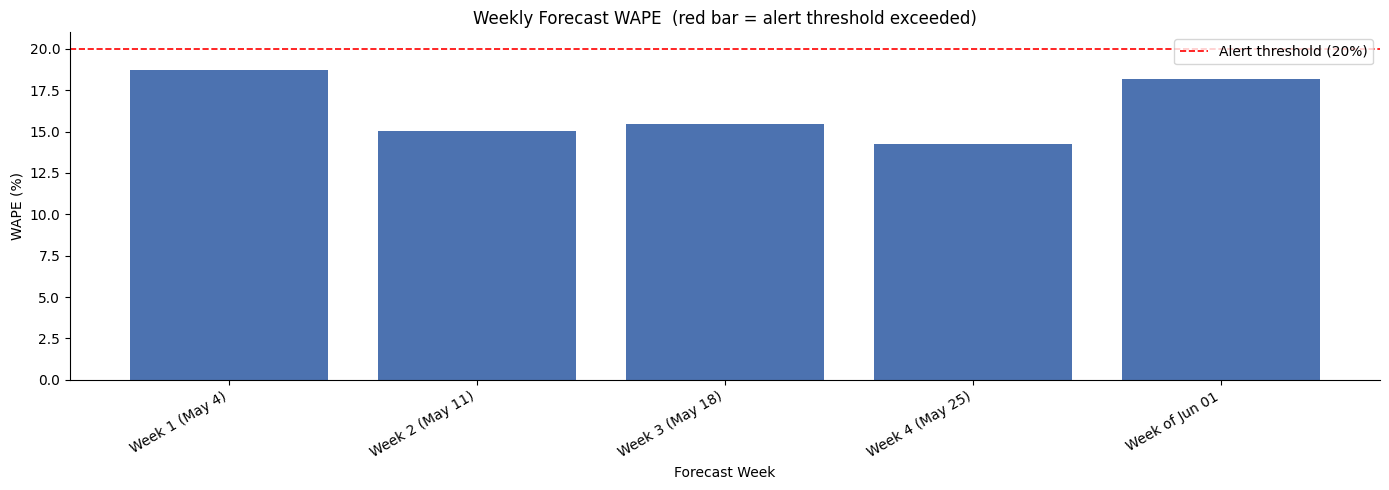

In [7]:
if len(weekly) > 0:
    fig, ax = plt.subplots(figsize=(14, 5))
    colors = ["#C44E52" if w > WAPE_ALERT_THRESHOLD * 100 else "#4C72B0" for w in weekly["WAPE"]]
    ax.bar(weekly["week_label"], weekly["WAPE"], color=colors)
    ax.axhline(WAPE_ALERT_THRESHOLD * 100, color="red", ls="--", lw=1.2,
               label=f"Alert threshold ({WAPE_ALERT_THRESHOLD:.0%})")
    ax.set_title("Weekly Forecast WAPE  (red bar = alert threshold exceeded)")
    ax.set_ylabel("WAPE (%)")
    ax.set_xlabel("Forecast Week")
    ax.legend()
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()
else:
    print("No evaluated weeks yet — run generate_weekly_forecast.py first, then wait for actuals to land in Supabase.")

### Chart 2 — Actual vs Predicted Units
> If the lines track each other closely, the model is doing its job.  
> A widening gap means the model is losing touch with reality — time to retrain.

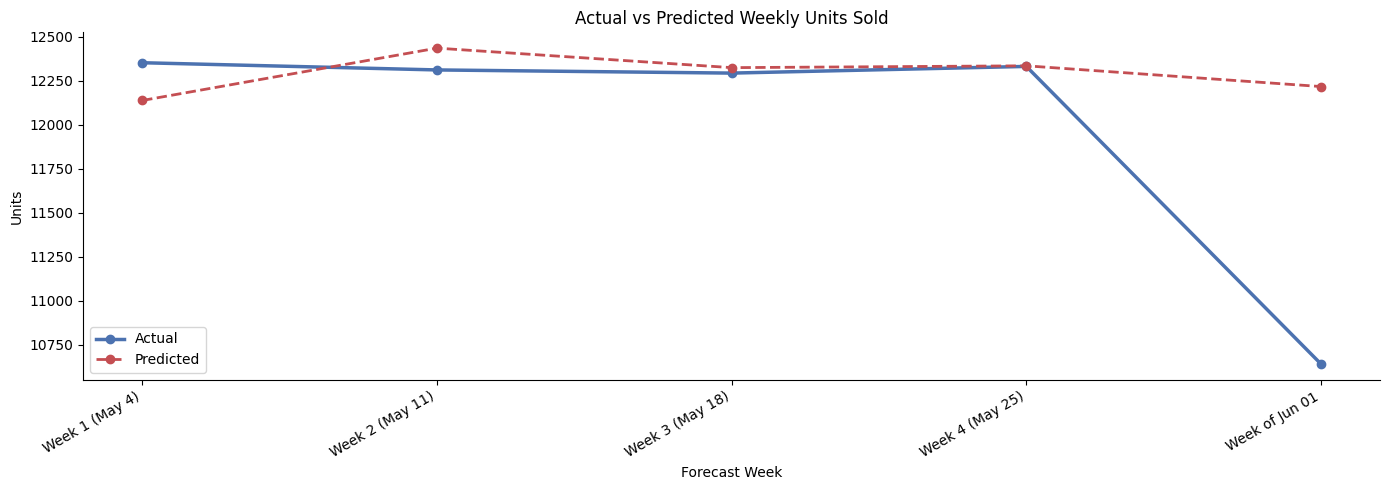

In [8]:
if len(weekly) > 0:
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(weekly["week_label"], weekly["actual_sum"],    marker="o", label="Actual",    color=PALETTE[0], lw=2.5)
    ax.plot(weekly["week_label"], weekly["predicted_sum"], marker="o", label="Predicted", color=PALETTE[1], lw=2, ls="--")
    ax.set_title("Actual vs Predicted Weekly Units Sold")
    ax.set_ylabel("Units")
    ax.set_xlabel("Forecast Week")
    ax.legend()
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()
else:
    print("No evaluated weeks yet.")

### Chart 3 — Bias Over Time
> Positive bias = model over-predicts (orders too much stock).  
> Negative bias = model under-predicts (risk of stockouts).  
> Both are bad — a good model hovers around 0.

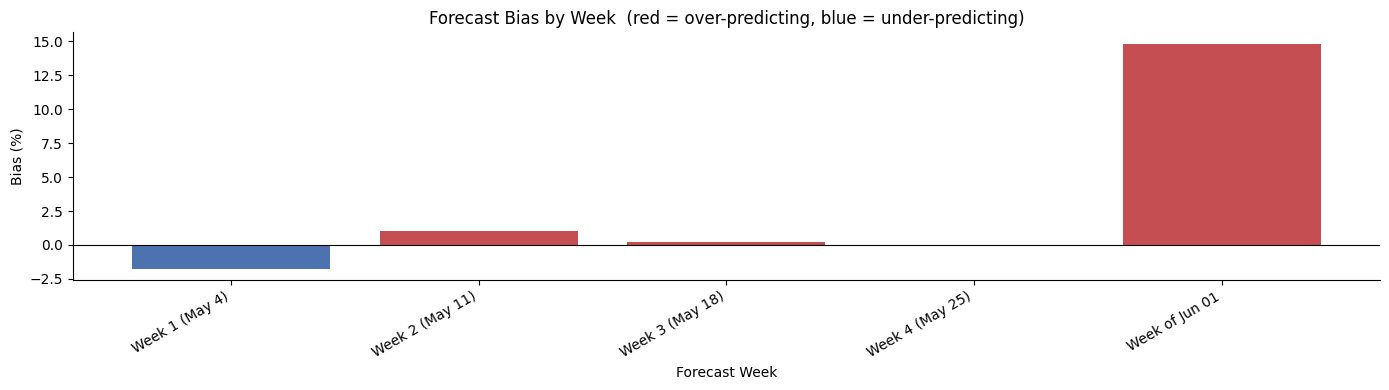

In [9]:
if len(weekly) > 0:
    fig, ax = plt.subplots(figsize=(14, 4))
    colors = ["#C44E52" if b > 0 else "#4C72B0" for b in weekly["BIAS_PCT"]]
    ax.bar(weekly["week_label"], weekly["BIAS_PCT"], color=colors)
    ax.axhline(0, color="black", lw=0.8)
    ax.set_title("Forecast Bias by Week  (red = over-predicting, blue = under-predicting)")
    ax.set_ylabel("Bias (%)")
    ax.set_xlabel("Forecast Week")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()
else:
    print("No evaluated weeks yet.")

---
## 7. Worst Performing Store × Product Combinations

> Pinpoints exactly which store-product pairs the model struggles with most.  
> These are candidates for separate models or manual overrides.

In [10]:
if len(evaluated) > 0:
    worst = (evaluated.groupby(["store_id", "product_id"])
             .agg(
                 avg_actual    =("units_sold",       "mean"),
                 avg_predicted =("predicted_units",  "mean"),
                 avg_abs_error =("abs_error",         "mean"),
                 wape          =("abs_error",         "sum"),
             )
             .reset_index())

    actual_sum_by_sp = evaluated.groupby(["store_id","product_id"])["units_sold"].sum()
    worst["wape"] = (worst["wape"] / worst["store_id"].map(
        evaluated.groupby("store_id")["units_sold"].sum()
    )).round(4)

    worst = worst.sort_values("avg_abs_error", ascending=False).head(20)
    worst["avg_actual"]    = worst["avg_actual"].round(2)
    worst["avg_predicted"] = worst["avg_predicted"].round(2)
    worst["avg_abs_error"] = worst["avg_abs_error"].round(2)

    print("Top 20 worst store × product combinations by average absolute error:")
    display(worst.reset_index(drop=True))
else:
    print("No evaluated rows yet.")

Top 20 worst store × product combinations by average absolute error:


,store_id,product_id,avg_actual,avg_predicted,avg_abs_error,wape
0,4,1095,156.4,106.83,59.70,0.0440
1,7,1095,129.2,145.60,39.26,0.0265
2,1,1029,271.2,303.77,39.11,0.0144
3,7,1104,144.6,119.88,36.50,0.0246
4,1,1104,185.0,216.71,32.45,0.0119
5,7,1052,147.4,138.58,31.86,0.0215
6,5,1071,116.2,109.00,31.17,0.0221
7,2,1071,230.8,234.88,29.78,0.0160
8,3,1029,191.6,207.02,28.47,0.0166
9,2,1095,125.6,141.68,23.49,0.0126


---
## 8. Future Weeks — Waiting for Actuals

> These forecast weeks don't have actuals yet.  
> They will become evaluable once you run the Saturday upload script.

In [11]:
pending = monitor[monitor["units_sold"].isna()][["week_start", "model_version"]].drop_duplicates()

if len(pending):
    print("Forecast weeks pending actuals:")
    display(pending.reset_index(drop=True))
    print(f"\nRun generate_upload_to_supabase.py after {pending['week_start'].max().date()} to unlock these.")
else:
    print("All forecast weeks have actuals — fully evaluated.")

Forecast weeks pending actuals:


,week_start,model_version
0,2026-06-08,weekly_model_v3_calendar_2026_05



Run generate_upload_to_supabase.py after 2026-06-08 to unlock these.
